In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import xgboost as xgb
import numpy as np
from matplotlib import pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-9/UCI_Credit_Card.csv")
df1

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,0,0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,0,0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,0,-1,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


# Preprocessing

In [3]:
df2 = df1.astype(float)
df2

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1.0,20000.0,2.0,2.0,1.0,24.0,2.0,2.0,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1.0
1,2.0,120000.0,2.0,2.0,2.0,26.0,-1.0,2.0,0.0,0.0,0.0,2.0,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1.0
2,3.0,90000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0.0
3,4.0,50000.0,2.0,2.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0.0
4,5.0,50000.0,1.0,2.0,1.0,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996.0,220000.0,1.0,3.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0.0
29996,29997.0,150000.0,1.0,3.0,2.0,43.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0.0
29997,29998.0,30000.0,1.0,2.0,2.0,37.0,4.0,3.0,2.0,-1.0,0.0,0.0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1.0
29998,29999.0,80000.0,1.0,3.0,1.0,41.0,1.0,-1.0,0.0,0.0,0.0,-1.0,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1.0


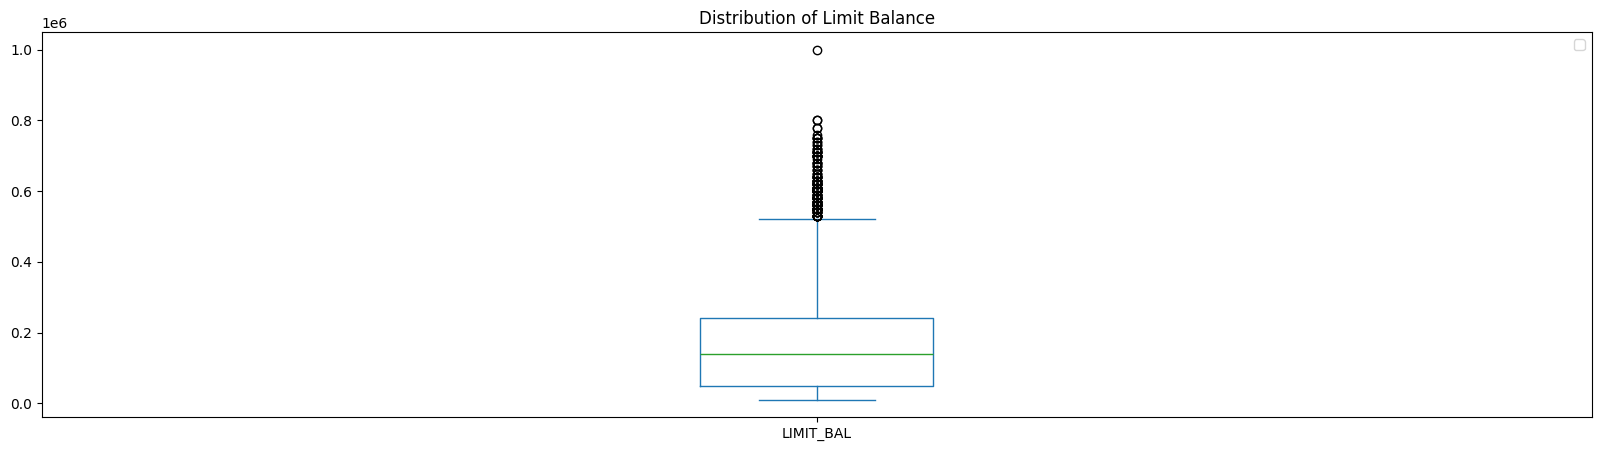

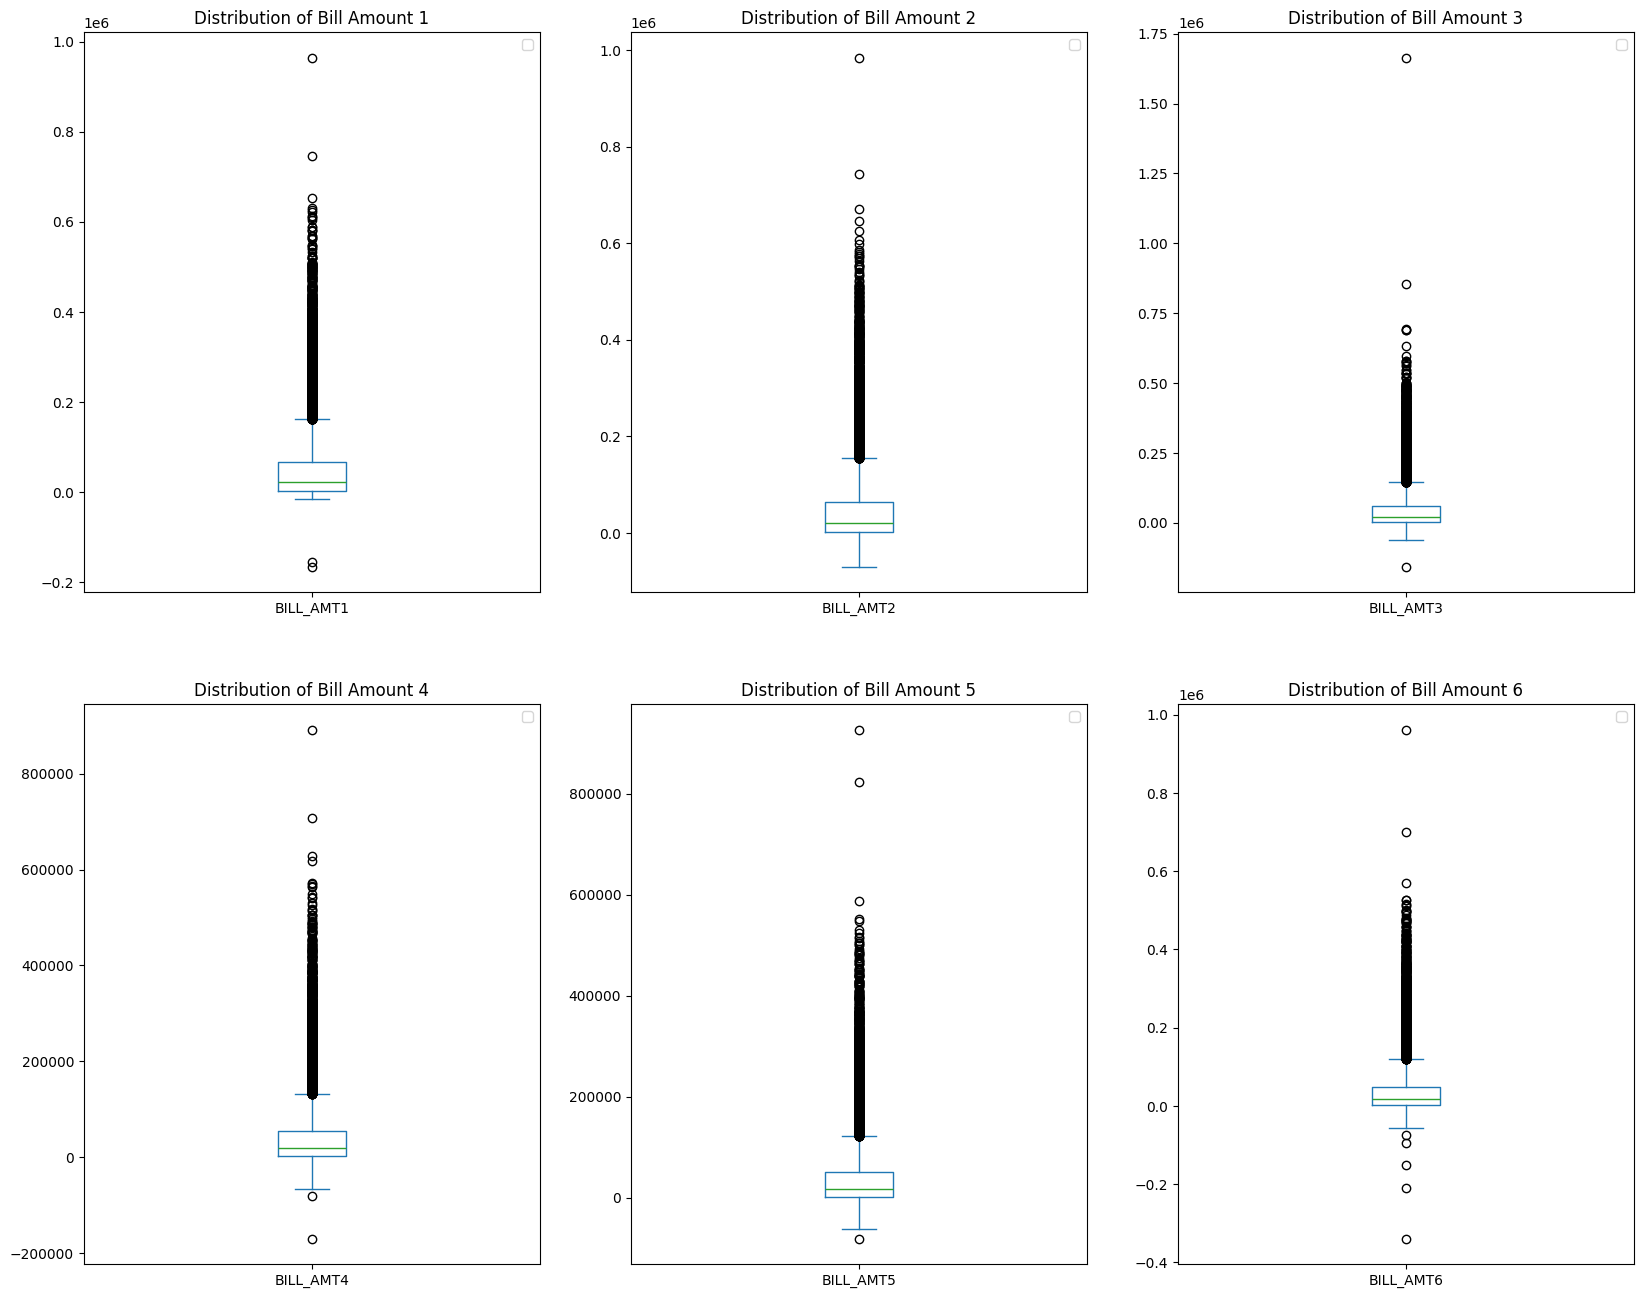

In [4]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 1, 1)
plt.title("Distribution of Limit Balance")
df2['LIMIT_BAL'].plot(kind='box')
plt.legend() 

plt.figure(figsize=(20, 16))
plt.subplot(2, 3, 1)
plt.title("Distribution of Bill Amount 1")
df2['BILL_AMT1'].plot(kind='box')
plt.legend() 

plt.subplot(2, 3, 2)
plt.title("Distribution of Bill Amount 2")
df2['BILL_AMT2'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 3)
plt.title("Distribution of Bill Amount 3")
df2['BILL_AMT3'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 4)
plt.title("Distribution of Bill Amount 4")
df2['BILL_AMT4'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 5)
plt.title("Distribution of Bill Amount 5")
df2['BILL_AMT5'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 6)
plt.title("Distribution of Bill Amount 6")
df2['BILL_AMT6'].plot(kind='box')
plt.legend()


plt.show()

iqr method to remove outliers..............

In [5]:
iqr_columns = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for column in iqr_columns:
    Q1 = df2[column].quantile(0.25)
    Q3 = df2[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df2 = df2[(df2[column] >= lower_bound) & (df2[column] <= upper_bound)]
    

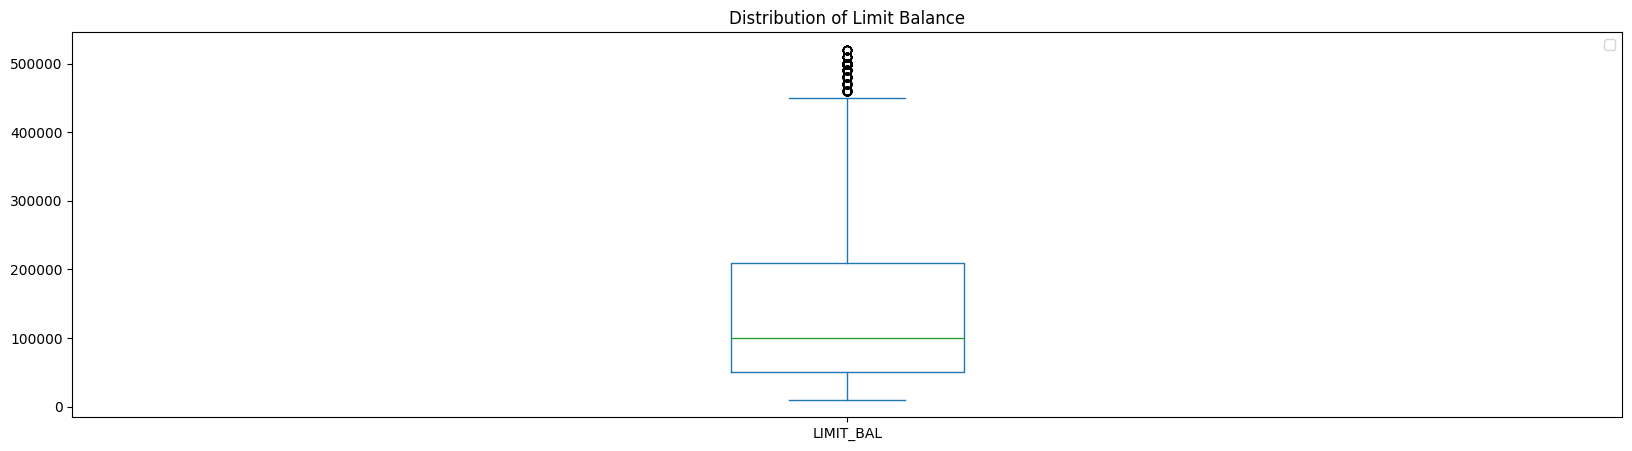

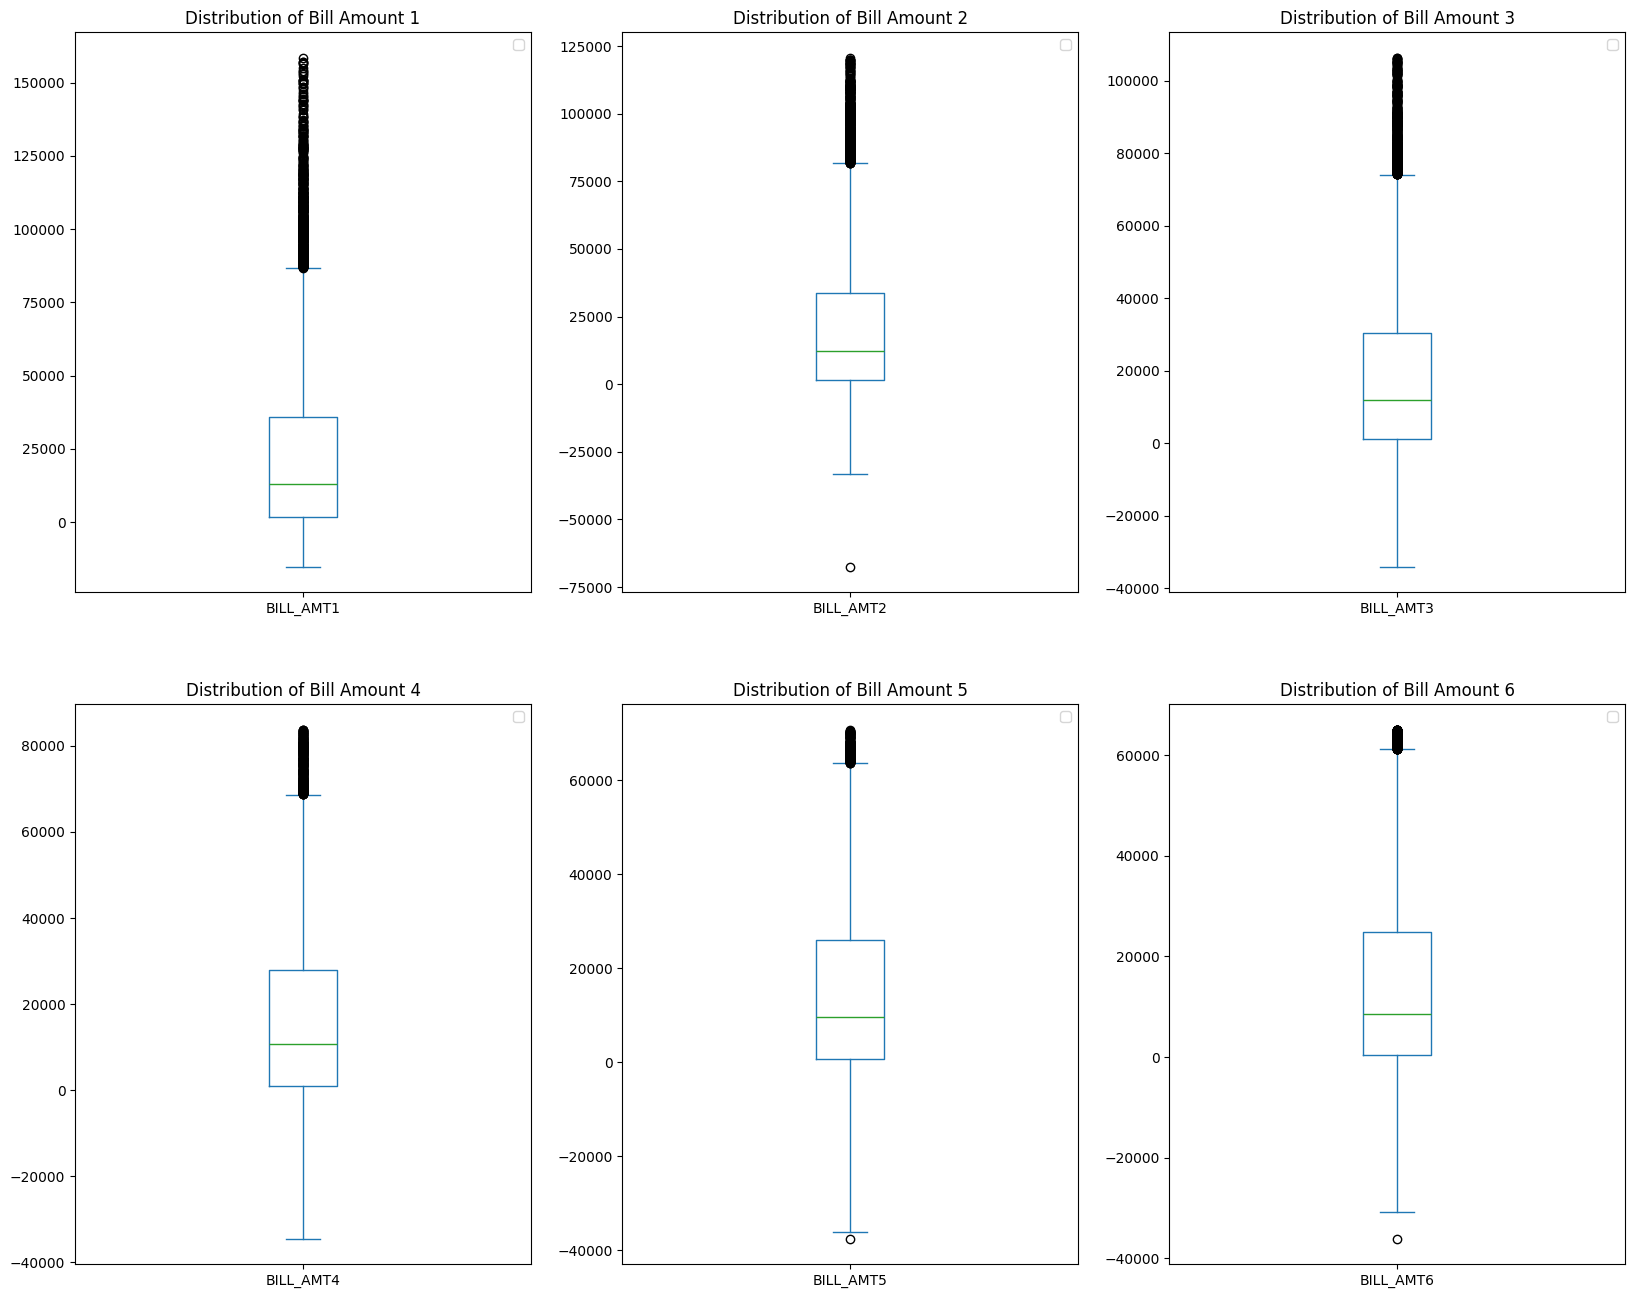

In [6]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 1, 1)
plt.title("Distribution of Limit Balance")
df2['LIMIT_BAL'].plot(kind='box')
plt.legend() 

plt.figure(figsize=(20, 16))
plt.subplot(2, 3, 1)
plt.title("Distribution of Bill Amount 1")
df2['BILL_AMT1'].plot(kind='box')
plt.legend() 

plt.subplot(2, 3, 2)
plt.title("Distribution of Bill Amount 2")
df2['BILL_AMT2'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 3)
plt.title("Distribution of Bill Amount 3")
df2['BILL_AMT3'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 4)
plt.title("Distribution of Bill Amount 4")
df2['BILL_AMT4'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 5)
plt.title("Distribution of Bill Amount 5")
df2['BILL_AMT5'].plot(kind='box')
plt.legend()

plt.subplot(2, 3, 6)
plt.title("Distribution of Bill Amount 6")
df2['BILL_AMT6'].plot(kind='box')
plt.legend()


plt.show()

In [7]:
df2

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1.0,20000.0,2.0,2.0,1.0,24.0,2.0,2.0,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1.0
1,2.0,120000.0,2.0,2.0,2.0,26.0,-1.0,2.0,0.0,0.0,0.0,2.0,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1.0
2,3.0,90000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0.0
3,4.0,50000.0,2.0,2.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0.0
4,5.0,50000.0,1.0,2.0,1.0,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,29994.0,100000.0,1.0,1.0,2.0,38.0,0.0,-1.0,-1.0,0.0,0.0,0.0,3042.0,1427.0,102996.0,70626.0,69473.0,55004.0,2000.0,111784.0,4000.0,3000.0,2000.0,2000.0,0.0
29996,29997.0,150000.0,1.0,3.0,2.0,43.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0.0
29997,29998.0,30000.0,1.0,2.0,2.0,37.0,4.0,3.0,2.0,-1.0,0.0,0.0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1.0
29998,29999.0,80000.0,1.0,3.0,1.0,41.0,1.0,-1.0,0.0,0.0,0.0,-1.0,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1.0


In [8]:
df2['util_avg_4'] = (((df2['BILL_AMT1']/df2['LIMIT_BAL'])+
                    (df2['BILL_AMT2']/df2['LIMIT_BAL'])+
                    (df2['BILL_AMT3']/df2['LIMIT_BAL'])+
                    (df2['BILL_AMT4']/df2['LIMIT_BAL']))/4).round(5)
df2['util_5'] = df2['BILL_AMT5']/df2['LIMIT_BAL'].round(5)
df2['util_6'] = df2['BILL_AMT6']/df2['LIMIT_BAL'].round(5)

In [9]:
df2['repay_avg_4'] = (((df2['PAY_AMT1']/df2['BILL_AMT1'])+
                   (df2['PAY_AMT2']/df2['BILL_AMT2'])+
                   (df2['PAY_AMT3']/df2['BILL_AMT3'])+
                   (df2['PAY_AMT4']/df2['BILL_AMT4']))/4).round(5)
df2['repay_5'] = df2['PAY_AMT5']/df2['BILL_AMT5'].round(5)
df2['repay_6'] = df2['PAY_AMT6']/df2['BILL_AMT6'].round(5)

In [10]:
df2

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,util_avg_4,util_5,util_6,repay_avg_4,repay_5,repay_6
0,1.0,20000.0,2.0,2.0,1.0,24.0,2.0,2.0,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1.0,0.09630,0.000000,0.000000,NaN,NaN,NaN
1,2.0,120000.0,2.0,2.0,2.0,26.0,-1.0,2.0,0.0,0.0,0.0,2.0,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1.0,0.02159,0.028792,0.027175,0.31455,0.000000,0.613309
2,3.0,90000.0,2.0,2.0,2.0,34.0,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0.0,0.19766,0.166089,0.172767,0.07560,0.066899,0.321564
3,4.0,50000.0,2.0,2.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0.0,0.86414,0.579180,0.590940,0.03690,0.036914,0.033844
4,5.0,50000.0,1.0,2.0,1.0,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0.0,0.35531,0.382920,0.382620,1.85257,0.035987,0.035492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,29994.0,100000.0,1.0,1.0,2.0,38.0,0.0,-1.0,-1.0,0.0,0.0,0.0,3042.0,1427.0,102996.0,70626.0,69473.0,55004.0,2000.0,111784.0,4000.0,3000.0,2000.0,2000.0,0.0,0.44523,0.694730,0.550040,19.76844,0.028788,0.036361
29996,29997.0,150000.0,1.0,3.0,2.0,43.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0.0,0.02665,0.034600,0.000000,1.40104,0.000000,NaN
29997,29998.0,30000.0,1.0,2.0,2.0,37.0,4.0,3.0,2.0,-1.0,0.0,0.0,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1.0,0.25464,0.686067,0.645233,2.04449,0.097172,0.160149
29998,29999.0,80000.0,1.0,3.0,1.0,41.0,1.0,-1.0,0.0,0.0,0.0,-1.0,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1.0,0.64316,0.148187,0.611800,-13.03085,4.467651,0.036858


In [11]:
df3 = pd.DataFrame()

In [12]:
df3['AGE']      = df2['AGE']
df3['PAY_0']    = df2['PAY_0']
df3['PAY_2']    = df2['PAY_2']
df3['PAY_3']    = df2['PAY_3']
df3['PAY_4']    = df2['PAY_4']
df3['PAY_5']    = df2['PAY_5']
df3['PAY_6']    = df2['PAY_6']
df3['util_avg_4'] = df2['util_avg_4']
df3['util_5']   = df2['util_5']
df3['util_6']   = df2['util_6']
df3['repay_avg_4'] = df2['repay_avg_4']
df3['repay_5']   = df2['repay_5']
df3['repay_6']   = df2['repay_6']
df3['default']   = df2['default.payment.next.month']

In [13]:
df3.to_csv(r"/Users/developer/Desktop/CarDefXGB1.csv", index=False)

In [14]:
cols = ['repay_avg_4', 'repay_5', 'repay_6']
for col in cols:
    med = df3[col].median()
    df3[col] = df3[col].fillna(med)    

In [15]:
df3.isnull().sum()  

AGE            0
PAY_0          0
PAY_2          0
PAY_3          0
PAY_4          0
PAY_5          0
PAY_6          0
util_avg_4     0
util_5         0
util_6         0
repay_avg_4    0
repay_5        0
repay_6        0
default        0
dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = df3.drop(['default'], axis='columns')
y = df3['default']
y

0        1.0
1        1.0
2        0.0
3        0.0
4        0.0
        ... 
29993    0.0
29996    0.0
29997    1.0
29998    1.0
29999    1.0
Name: default, Length: 22944, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
X_train.replace([np.inf, -np.inf], 0.0, inplace=True)
X_test.replace([np.inf, -np.inf], 0.0, inplace=True)
y_train.replace([np.inf, -np.inf], 0.0, inplace=True)
y_test.replace([np.inf, -np.inf], 0.0, inplace=True)

24431    1.0
12058    0.0
14054    0.0
9544     0.0
13012    0.0
        ... 
4102     1.0
19026    1.0
2650     1.0
4189     0.0
11743    0.0
Name: default, Length: 4589, dtype: float64

In [19]:
y_train.value_counts()

default
0.0    14169
1.0     4186
Name: count, dtype: int64

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
modelLR = LogisticRegression(penalty='l2'
                             , C=0.5
                             , max_iter=500)
modelLR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [22]:
modelLR.score(X_test, y_test)

0.793636957942907

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predictions
y_pred = modelLR.predict(X_test)

# Accuracy
accuracy = round(accuracy_score(y_test, y_pred), 2)

# Precision
precision = round(precision_score(y_test, y_pred, average='weighted'), 2)

# Recall
recall = round(recall_score(y_test, y_pred, average='weighted'), 2)

# F1 Score
f1 = round(f1_score(y_test, y_pred, average='weighted'), 2)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:\n", conf_matrix)

# Optional (clean summary)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.79
Precision: 0.77
Recall: 0.79
F1 Score: 0.74

Confusion Matrix:
 [[3446   90]
 [ 857  196]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.80      0.97      0.88      3536
         1.0       0.69      0.19      0.29      1053

    accuracy                           0.79      4589
   macro avg       0.74      0.58      0.59      4589
weighted avg       0.77      0.79      0.74      4589



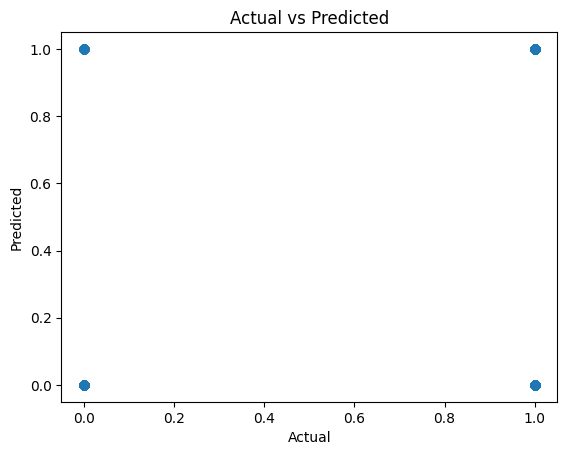

In [26]:
y_pred = modelLR.predict(X_test)

plt.scatter(y_test, y_pred)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()